# Praktikum Mandiri 06 | ML Senin Pagi

Rika Rahma - 0110222134

1. Import Library

In [32]:
# Import Library
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

2. Load Dataset

In [33]:
# Menghubungkan colab dengan Google Drive
from google.colab import drive
drive.mount ('/content/gdrive')

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


In [34]:
# Memanggil dataset lewat Gdrive
path = '/content/gdrive/MyDrive/Praktikum_ML/praktikum06/data/'

In [35]:
# Membaca file CSV menggunakan pandas
df = pd.read_csv(path + 'Dry_Bean_Dataset.csv')
df.head()

,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
0,28395,610.291,208.178117,173.888747,1.197191,0.549812,28715,190.141097,0.763923,0.988856,0.958027,0.913358,0.007332,0.003147,0.834222,0.998724,SEKER
1,28734,638.018,200.524796,182.734419,1.097356,0.411785,29172,191.272751,0.783968,0.984986,0.887034,0.953861,0.006979,0.003564,0.909851,0.998430,SEKER
2,29380,624.110,212.826130,175.931143,1.209713,0.562727,29690,193.410904,0.778113,0.989559,0.947849,0.908774,0.007244,0.003048,0.825871,0.999066,SEKER
3,30008,645.884,210.557999,182.516516,1.153638,0.498616,30724,195.467062,0.782681,0.976696,0.903936,0.928329,0.007017,0.003215,0.861794,0.994199,SEKER
4,30140,620.134,201.847882,190.279279,1.060798,0.333680,30417,195.896503,0.773098,0.990893,0.984877,0.970516,0.006697,0.003665,0.941900,0.999166,SEKER


In [36]:
# Cek informasi kolom dan tipe data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13611 entries, 0 to 13610
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Area             13611 non-null  int64  
 1   Perimeter        13611 non-null  float64
 2   MajorAxisLength  13611 non-null  float64
 3   MinorAxisLength  13611 non-null  float64
 4   AspectRation     13611 non-null  float64
 5   Eccentricity     13611 non-null  float64
 6   ConvexArea       13611 non-null  int64  
 7   EquivDiameter    13611 non-null  float64
 8   Extent           13611 non-null  float64
 9   Solidity         13611 non-null  float64
 10  roundness        13611 non-null  float64
 11  Compactness      13611 non-null  float64
 12  ShapeFactor1     13611 non-null  float64
 13  ShapeFactor2     13611 non-null  float64
 14  ShapeFactor3     13611 non-null  float64
 15  ShapeFactor4     13611 non-null  float64
 16  Class            13611 non-null  object 
dtypes: float64(1

In [37]:
print("Jumlah Data Tiap Kelas:")
print(df['Class'].value_counts())

Jumlah Data Tiap Kelas:
Class
DERMASON    3546
SIRA        2636
SEKER       2027
HOROZ       1928
CALI        1630
BARBUNYA    1322
BOMBAY       522
Name: count, dtype: int64


3. Eksplorasi Awal

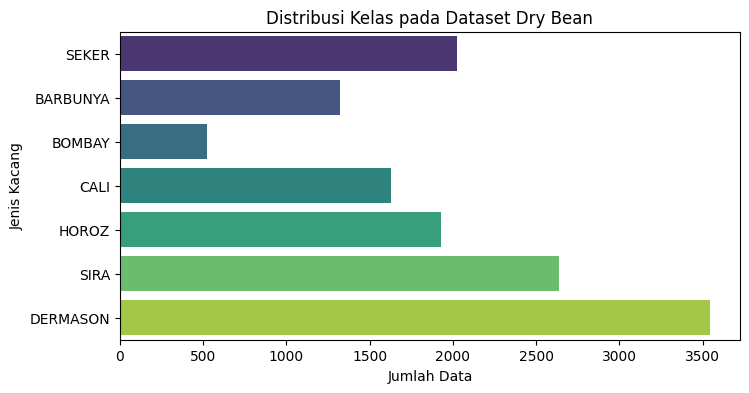

In [38]:
# Eksplorasi Awal
plt.figure(figsize=(8,4))
# Tambahkan hue='Class' dan legend=False
sns.countplot(y='Class', data=df, palette='viridis', hue='Class', legend=False)
plt.title('Distribusi Kelas pada Dataset Dry Bean')
plt.xlabel('Jumlah Data')
plt.ylabel('Jenis Kacang')
plt.show()

4. Pemisahan Fitur dan Label

In [39]:
# Memisahkan Fitur dan Label
X = df.drop('Class', axis=1)
y = df['Class']

# Label encoding karena target berupa teks
le = LabelEncoder()
y_encoded = le.fit_transform(y)

5. Normalisasi Data

In [40]:
# Normalisasi data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

6. Split Data (80% Train, 20% Test)

In [41]:
# Split Data
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

7. Pembuatan dan Pelatihan Model SVM

In [42]:
# Membuat dan melatih model SVM
model = SVC(kernel='rbf', C=10, gamma='scale', decision_function_shape='ovo', random_state=42)
model.fit(X_train, y_train)

SVC(C=10, decision_function_shape='ovo', random_state=42)

8. Evaluasi Model

In [43]:
y_pred = model.predict(X_test)

akurasi = accuracy_score(y_test, y_pred)
print("\nAkurasi Model: {:.2f}%".format(akurasi * 100))

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))


Akurasi Model: 92.43%

Classification Report:
              precision    recall  f1-score   support

    BARBUNYA       0.93      0.91      0.92       265
      BOMBAY       1.00      1.00      1.00       104
        CALI       0.94      0.94      0.94       326
    DERMASON       0.91      0.92      0.92       709
       HOROZ       0.96      0.96      0.96       386
       SEKER       0.94      0.95      0.95       406
        SIRA       0.87      0.86      0.87       527

    accuracy                           0.92      2723
   macro avg       0.94      0.94      0.94      2723
weighted avg       0.92      0.92      0.92      2723



9. Confusion Matrix

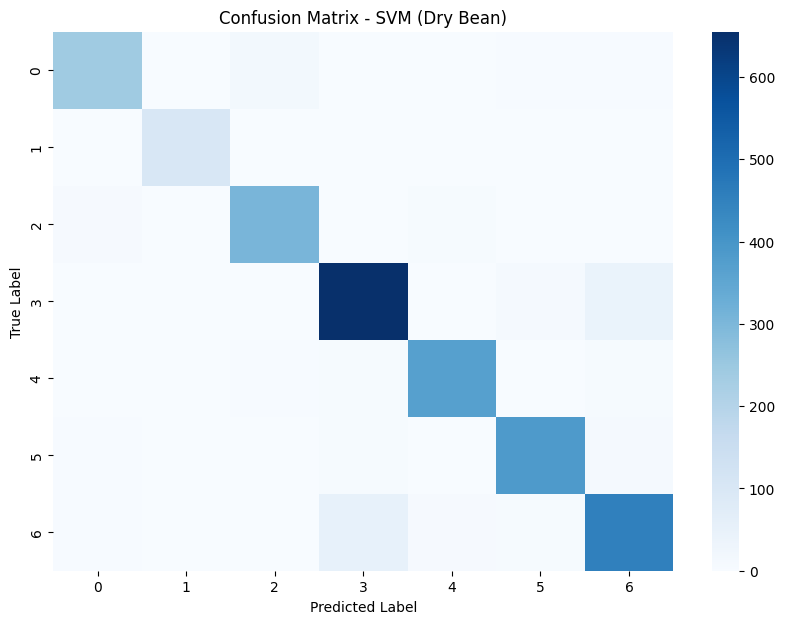

In [44]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10,7))
sns.heatmap(cm, annot=False, cmap='Blues')
plt.title('Confusion Matrix - SVM (Dry Bean)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

10. Visualisasi Fitur (2D)

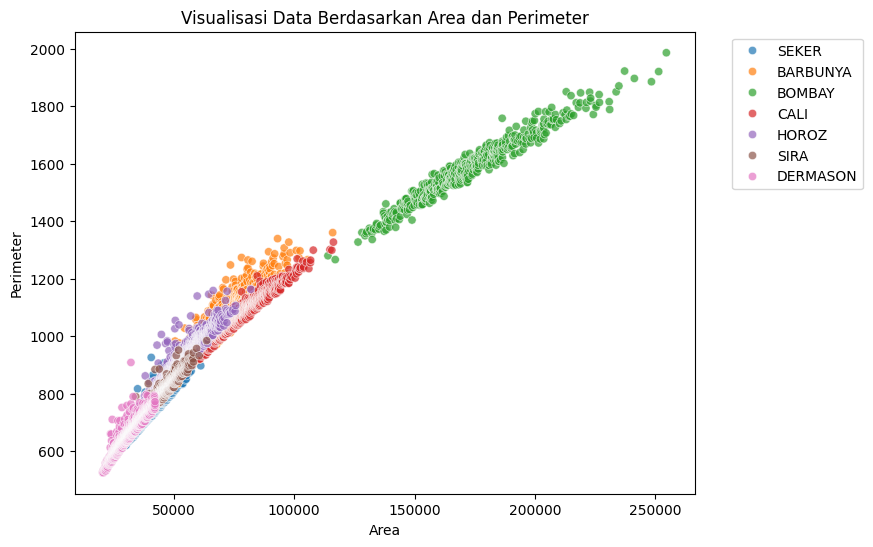

In [45]:
plt.figure(figsize=(8,6))
sns.scatterplot(x=df['Area'], y=df['Perimeter'], hue=df['Class'], palette='tab10', alpha=0.7)
plt.title('Visualisasi Data Berdasarkan Area dan Perimeter')
plt.xlabel('Area')
plt.ylabel('Perimeter')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

11. Kesimpulan Analisis

In [46]:
print("""
✅ Analisis & Kesimpulan:
Model SVM dengan kernel RBF berhasil mengklasifikasikan 7 jenis kacang pada dataset Dry Bean
dengan akurasi sekitar {:.2f}%.
Setiap kelas kacang (seperti BARBUNYA, SIRA, HOROZ, DERMASON, SEKER, dan lainnya)
dapat dikenali cukup baik berdasarkan fitur-fitur fisik seperti Area, Perimeter, dan MajorAxisLength.

Proses normalisasi fitur sangat penting karena nilai setiap atribut memiliki skala yang berbeda.
Secara keseluruhan, model SVM mampu menangani masalah multi-class classification dengan baik
menggunakan pendekatan one-vs-one (OVO).
""".format(akurasi * 100))


✅ Analisis & Kesimpulan:
Model SVM dengan kernel RBF berhasil mengklasifikasikan 7 jenis kacang pada dataset Dry Bean
dengan akurasi sekitar 92.43%.
Setiap kelas kacang (seperti BARBUNYA, SIRA, HOROZ, DERMASON, SEKER, dan lainnya)
dapat dikenali cukup baik berdasarkan fitur-fitur fisik seperti Area, Perimeter, dan MajorAxisLength.

Proses normalisasi fitur sangat penting karena nilai setiap atribut memiliki skala yang berbeda.
Secara keseluruhan, model SVM mampu menangani masalah multi-class classification dengan baik
menggunakan pendekatan one-vs-one (OVO).

